<a href="https://colab.research.google.com/github/guguberg/Fake-News-Detection/blob/main/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Task 1: Flags per Landmass ---
landmass
4    52
5    39
3    35
1    31
6    20
2    17
Name: count, dtype: int64


--- Task 2: Data Filtered for Europe & Oceania ---
Shape: (55, 30)


--- Task 4: Variable Types ---
red          int64
green        int64
blue         int64
gold         int64
white        int64
black        int64
orange       int64
mainhue     object
bars         int64
stripes      int64
circles      int64
crosses      int64
saltires     int64
quarters     int64
sunstars     int64
triangle     int64
animate      int64
dtype: object


--- Task 5: Dummy Variables Created ---
New Data Shape: (55, 22)




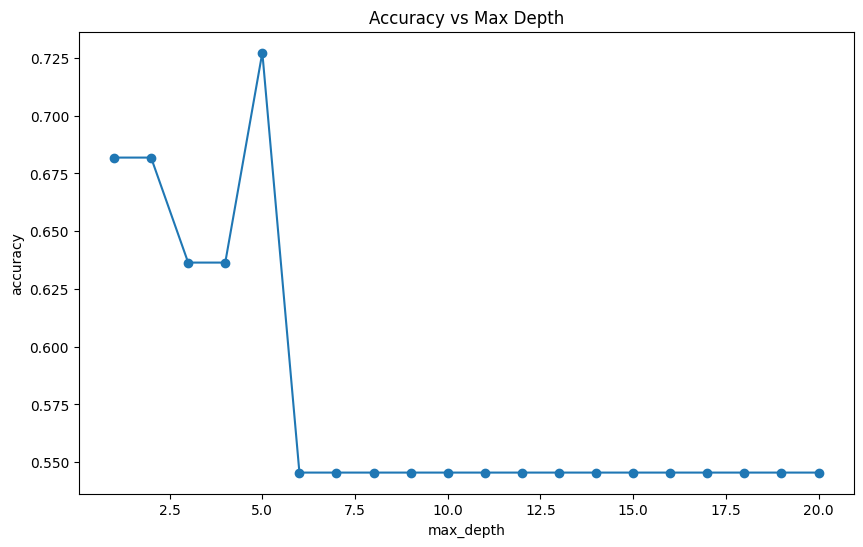

--- Task 9: Best Results ---
Highest Accuracy: 0.7272727272727273
Optimal Depth: 5




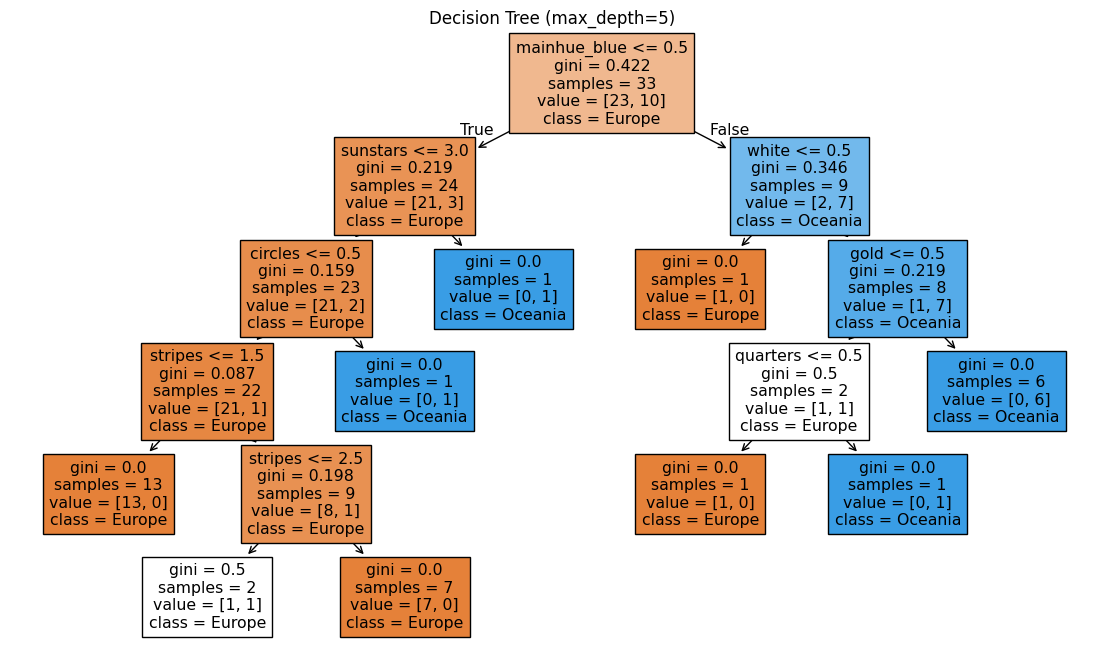

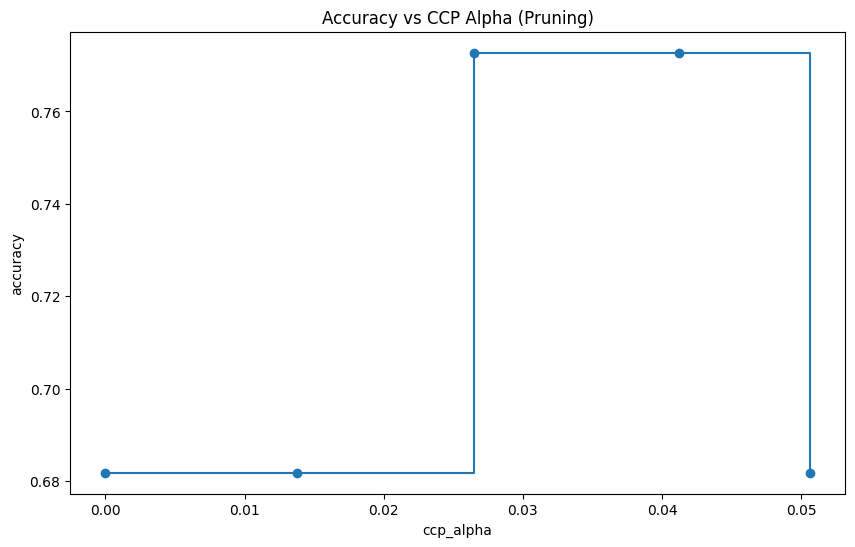

--- Task 13: Best Pruned Results ---
Highest Pruned Accuracy: 0.7727272727272727
Optimal ccp_alpha: 0.026515151515151516




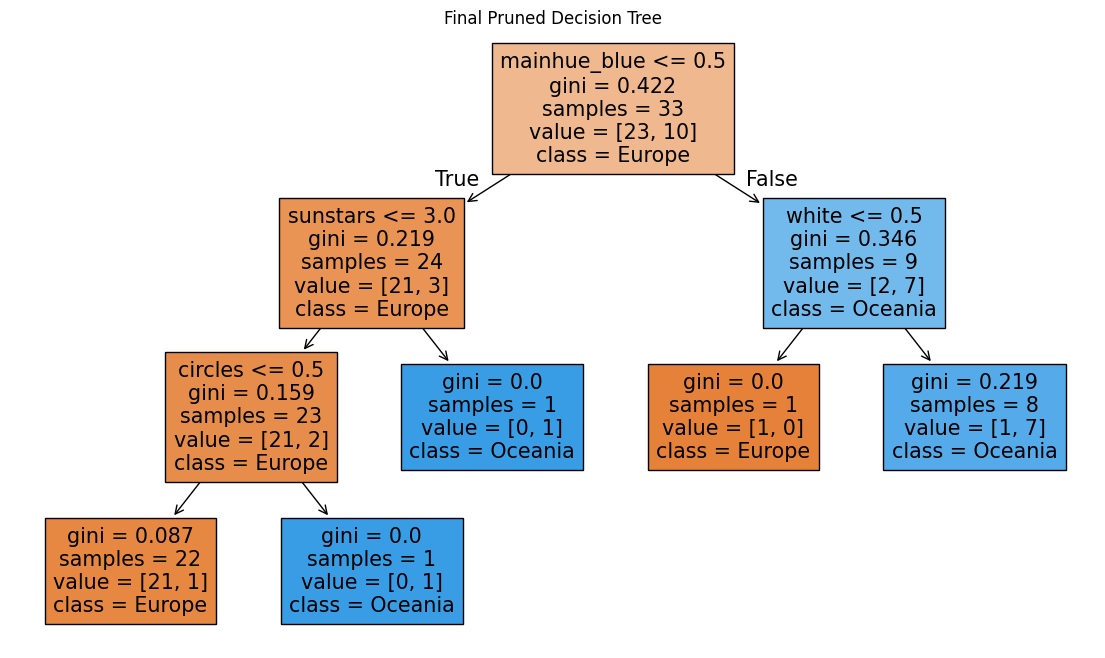

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# --- Load Data ---
cols = ['name','landmass','zone', 'area', 'population', 'language','religion','bars','stripes','colours',
'red','green','blue','gold','white','black','orange','mainhue','circles',
'crosses','saltires','quarters','sunstars','crescent','triangle','icon','animate','text','topleft','botright']
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/flags/flag.data", names = cols)

# variable names to use as predictors
var = [ 'red', 'green', 'blue','gold', 'white', 'black', 'orange', 'mainhue','bars','stripes', 'circles','crosses', 'saltires','quarters','sunstars','triangle','animate']

# --- Task 1: Print number of countries by landmass ---
# 1=N.America, 2=S.America, 3=Europe, 4=Africa, 5=Asia, 6=Oceania
print("--- Task 1: Flags per Landmass ---")
print(df['landmass'].value_counts())
print("\n")

# --- Task 2: Create a new dataframe with only flags from Europe (3) and Oceania (6) ---
df_36 = df[df["landmass"].isin([3, 6])]
print("--- Task 2: Data Filtered for Europe & Oceania ---")
print(f"Shape: {df_36.shape}")
print("\n")


# --- Task 4: Print the variable types for the predictors ---
print("--- Task 4: Variable Types ---")
print(df_36[var].dtypes)
print("\n")

# --- Task 5: Create dummy variables for categorical predictors ---
# 'mainhue' is categorical (text), so we convert it to numeric dummy variables
data = pd.get_dummies(df_36[var])
print("--- Task 5: Dummy Variables Created ---")
print(f"New Data Shape: {data.shape}")
print("\n")

# --- Task 6: Split data into a train and test set ---
# We are predicting 'landmass'
labels = df_36["landmass"]
train_data, test_data, train_labels, test_labels = train_test_split(data, labels, random_state=1, test_size=.4)

# --- Task 7: Tune Decision Tree Classifiers by Depth ---
depths = range(1, 21)
acc_depth = []

for i in depths:
    dt = DecisionTreeClassifier(random_state=10, max_depth=i)
    dt.fit(train_data, train_labels)
    acc_depth.append(dt.score(test_data, test_labels))

# --- Task 8: Plot the accuracy vs depth ---
plt.figure(figsize=(10, 6))
plt.plot(depths, acc_depth, marker='o')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.title('Accuracy vs Max Depth')
plt.show()

# --- Task 9: Find the largest accuracy and the depth this occurs ---
max_acc = np.max(acc_depth)
best_depth = depths[np.argmax(acc_depth)]
print(f"--- Task 9: Best Results ---")
print(f"Highest Accuracy: {max_acc}")
print(f"Optimal Depth: {best_depth}")
print("\n")

# --- Task 10: Refit decision tree model with the highest accuracy and plot ---
plt.figure(figsize=(14, 8))
dt_best = DecisionTreeClassifier(random_state=1, max_depth=best_depth)
dt_best.fit(train_data, train_labels)
tree.plot_tree(dt_best, feature_names=list(data.columns), class_names=['Europe', 'Oceania'], filled=True)
plt.title(f'Decision Tree (max_depth={best_depth})')
plt.show()

# --- Task 11: Tune Decision Tree Classifiers by Pruning ---
# We generate a path of effective alphas to test
path = dt_best.cost_complexity_pruning_path(train_data, train_labels)
ccp_alphas = path.ccp_alphas
ccp_alphas = ccp_alphas[:-1] # Remove the max alpha (which leaves only the root)

acc_pruned = []

for alpha in ccp_alphas:
    dt_prune = DecisionTreeClassifier(random_state=1, max_depth=best_depth, ccp_alpha=alpha)
    dt_prune.fit(train_data, train_labels)
    acc_pruned.append(dt_prune.score(test_data, test_labels))

# --- Task 12: Plot the accuracy vs ccp_alpha ---
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, acc_pruned, marker='o', drawstyle="steps-post")
plt.xlabel('ccp_alpha')
plt.ylabel('accuracy')
plt.title('Accuracy vs CCP Alpha (Pruning)')
plt.show()

# --- Task 13: Find the largest accuracy and the ccp value this occurs ---
max_acc_pruned = np.max(acc_pruned)
# Note: There might be multiple alphas with the same accuracy, taking the last one typically gives the simplest tree
best_ccp = ccp_alphas[np.argmax(acc_pruned)]
print(f"--- Task 13: Best Pruned Results ---")
print(f"Highest Pruned Accuracy: {max_acc_pruned}")
print(f"Optimal ccp_alpha: {best_ccp}")
print("\n")

# --- Task 14: Fit a decision tree model with the values found above ---
dt_final = DecisionTreeClassifier(random_state=1, max_depth=best_depth, ccp_alpha=best_ccp)
dt_final.fit(train_data, train_labels)

plt.figure(figsize=(14, 8))
tree.plot_tree(dt_final, feature_names=list(data.columns), class_names=['Europe', 'Oceania'], filled=True)
plt.title(f'Final Pruned Decision Tree')
plt.show()